# Maps SO


Para realizar las simulaciones con $sotodlib$, es necesario instalar dicha librería y $toast$ (todo desde github). Luego, para realizar mapmaking, se llama la instrucción $toast_so_sim$, donde es necesario tener un archivo de configuración, la carpeta de salida, las bandas de observación (En LAT y SAT se encuentran las siguientes:$f030 (27 GHz), f040(39 GHz), f090 (93 GHz), f150 ( 145 GHz), f230 (225 GHz), f290 (285 GHz) $), telescopio a utilizar (LAT, SAT1, SAT2, SAT3, SAT4), el schedule y un mapa de entrada (que se puede generar con camb). 

In [2]:
# librerías utiles
import healpy as hp
import matplotlib.pyplot as plt
import numpy as np
import os
from astropy.io import fits
from astropy.table import Table
import camb

In [3]:
# primero generamos nuestro mapa de entrada con solo señal de CMB 

pars = camb.CAMBparams()
#ombh2 = densidad de bariones
#omch2 = densidad materia oscura
#omk = omega de curvatura 
#mnu = suma de neutrinos
#tau = optical depth
pars.set_cosmology(H0=67.5, ombh2=0.022, omch2=0.122, mnu=0.06, omk=0, tau=0.06)
#As = comoving curvature power
#ns = índice espectral escalar
#r = tensor to scalar ratio
pars.InitPower.set_params(As=2*(10**-9), ns=0.965, r=0)
pars.set_for_lmax(5000, lens_potential_accuracy=0)

# se calculan los power spectra
results = camb.get_results(pars)
powers = results.get_cmb_power_spectra(pars, CMB_unit='muK')
totCl = powers['total']

ls = np.arange(totCl.shape[0])
cl_tt = totCl[:, 0]
cl_ee = totCl[:, 1]
cl_bb = totCl[:, 2]
cl_te = totCl[:, 3]

# dada la cosmología simulamos un mapa con synfast
nside = 512
simulated_map = hp.synfast([cl_tt, cl_ee, cl_bb, cl_te], nside=nside, new=1)

In [4]:
# guardamos los mapas con healpy
filename = "cmb_input_sim.fits"
hp.write_map(filename, simulated_map, overwrite=True, column_names=['TEMPERATURE', 'Q_POLARIZATION', 'U_POLARIZATION'])

setting the output map dtype to [dtype('float64'), dtype('float64'), dtype('float64')]


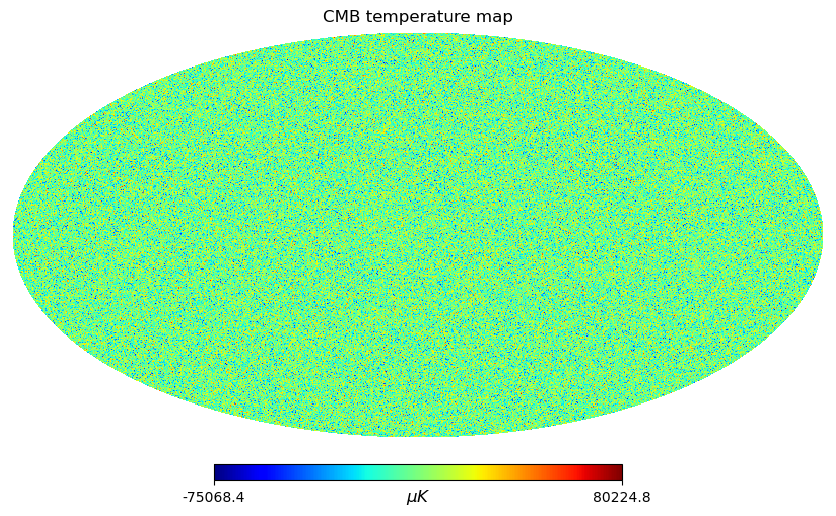

In [5]:
# plot
hp.mollview(simulated_map[0], cmap='jet', unit=r'$\mu K$', title= 'CMB temperature map')

In [ ]:
# líneas de código para hacer simulaciones en la terminal

toast_so_sim \
    --config config_final.toml \
    --out_dir out_sat_test_ \
    --bands SAT_f150 \
    --schedule ./schedules/schedule_sat_valid.txt \
    --telescope SAT1 \
    --scan_map.enable \
    --scan_map.file ./input/cmb_input_sim.fits \
    --pixels_healpix_radec.nside 512 \
    --thinfp 32 \
    --sample_rate 10 \
    --obsmaps

In [6]:
# archivos a cargar
carpeta = "/home/matias/Documentos/PhD/MapMaking/simulaciones/out_sat_test_thinfp"
archivo_mapa =  carpeta + "/mapmaker_map.fits"
archivo_mapa_cov = carpeta + "/mapmaker_cov.fits"
archivo_mapa_rcond = carpeta + "/mapmaker_rcond.fits"
archivo_hits = carpeta + "/mapmaker_hits.fits"

mapas = (archivo_mapa, archivo_mapa_cov, archivo_mapa_rcond, archivo_hits)

In [7]:
# se abren el archivo de mapas
with fits.open(mapas[0]) as hdul:

    mapmaker_map = hdul[1].data 

    dict_mapmaker_map = hdul[1].header 

    hdul.info()

# cargamos mapas T, Q y U
T_map = mapmaker_map['TEMPERATURE']
Q_map = mapmaker_map['Q_POLARISATION']
U_map = mapmaker_map['U_POLARISATION']

# diccionario 
dict_mapmaker_map

Filename: /home/matias/Documentos/PhD/MapMaking/simulaciones/out_sat_test_thinfp/mapmaker_map.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1  xtension      1 BinTableHDU     32   3145728R x 3C   ['E', 'E', 'E']   


XTENSION= 'BINTABLE'           / binary table extension                         
BITPIX  =                    8 / array data type                                
NAXIS   =                    2 / number of array dimensions                     
NAXIS1  =                   12 / length of dimension 1                          
NAXIS2  =              3145728 / length of dimension 2                          
PCOUNT  =                    0 / number of group parameters                     
GCOUNT  =                    1 / number of groups                               
TFIELDS =                    3 / number of table fields                         
TTYPE1  = 'TEMPERATURE'                                                         
TFORM1  = 'E       '                                                            
TTYPE2  = 'Q_POLARISATION'                                                      
TFORM2  = 'E       '                                                            
TTYPE3  = 'U_POLARISATION'  

In [8]:
# se abren el archivo de mapas
with fits.open(mapas[1]) as hdul:

    mapmaker_cov = hdul[1].data 

    dict_mapmaker_cov = hdul[1].header 

    hdul.info()

#mapas
II_map = mapmaker_cov['II']
IQ_map = mapmaker_cov['IQ']
IU_map = mapmaker_cov['IU']
QQ_map = mapmaker_cov['QQ']
QU_map = mapmaker_cov['QU']
UU_map = mapmaker_cov['UU']

dict_mapmaker_cov


Filename: /home/matias/Documentos/PhD/MapMaking/simulaciones/out_sat_test_thinfp/mapmaker_cov.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1  xtension      1 BinTableHDU     41   3145728R x 6C   ['E', 'E', 'E', 'E', 'E', 'E']   


XTENSION= 'BINTABLE'           / binary table extension                         
BITPIX  =                    8 / array data type                                
NAXIS   =                    2 / number of array dimensions                     
NAXIS1  =                   24 / length of dimension 1                          
NAXIS2  =              3145728 / length of dimension 2                          
PCOUNT  =                    0 / number of group parameters                     
GCOUNT  =                    1 / number of groups                               
TFIELDS =                    6 / number of table fields                         
TTYPE1  = 'II      '                                                            
TFORM1  = 'E       '                                                            
TTYPE2  = 'IQ      '                                                            
TFORM2  = 'E       '                                                            
TTYPE3  = 'IU      '        

In [9]:
# se abren el archivo de mapas
with fits.open(mapas[2]) as hdul:

    mapmaker_rcond = hdul[1].data 

    dict_mapmaker_rcond = hdul[1].header 

    hdul.info()

T_rcond_map = mapmaker_rcond['T']

dict_mapmaker_rcond

Filename: /home/matias/Documentos/PhD/MapMaking/simulaciones/out_sat_test_thinfp/mapmaker_rcond.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1  xtension      1 BinTableHDU     21   3145728R x 1C   ['E']   


XTENSION= 'BINTABLE'           / binary table extension                         
BITPIX  =                    8 / array data type                                
NAXIS   =                    2 / number of array dimensions                     
NAXIS1  =                    4 / length of dimension 1                          
NAXIS2  =              3145728 / length of dimension 2                          
PCOUNT  =                    0 / number of group parameters                     
GCOUNT  =                    1 / number of groups                               
TFIELDS =                    1 / number of table fields                         
TTYPE1  = 'T       '                                                            
TFORM1  = 'E       '                                                            
PIXTYPE = 'HEALPIX '           / HEALPIX pixelisation                           
ORDERING= 'NESTED  '           / Pixel ordering scheme, either RING or NESTED   
EXTNAME = 'xtension'        

In [11]:
# se abren el archivo de mapas
with fits.open(mapas[3]) as hdul:

    mapmaker_hits = hdul[1].data 

    dict_mapmaker_hits = hdul[1].header 

    hdul.info()

hits_map = mapmaker_hits['T']

dict_mapmaker_hits



Filename: /home/matias/Documentos/PhD/MapMaking/simulaciones/out_sat_test_thinfp/mapmaker_hits.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1  xtension      1 BinTableHDU     21   3145728R x 1C   ['J']   


XTENSION= 'BINTABLE'           / binary table extension                         
BITPIX  =                    8 / array data type                                
NAXIS   =                    2 / number of array dimensions                     
NAXIS1  =                    4 / length of dimension 1                          
NAXIS2  =              3145728 / length of dimension 2                          
PCOUNT  =                    0 / number of group parameters                     
GCOUNT  =                    1 / number of groups                               
TFIELDS =                    1 / number of table fields                         
TTYPE1  = 'T       '                                                            
TFORM1  = 'J       '                                                            
PIXTYPE = 'HEALPIX '           / HEALPIX pixelisation                           
ORDERING= 'NESTED  '           / Pixel ordering scheme, either RING or NESTED   
EXTNAME = 'xtension'        

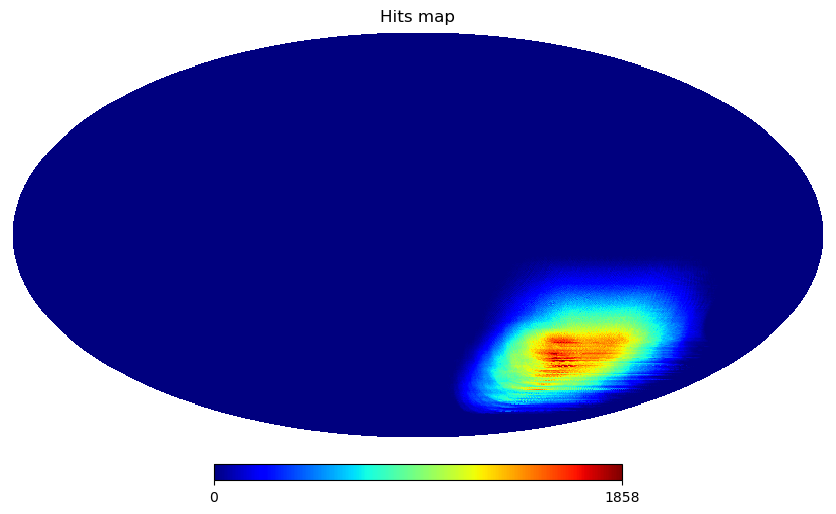

In [12]:
hp.mollview(hits_map, cmap='jet', nest= 1, title = 'Hits map')

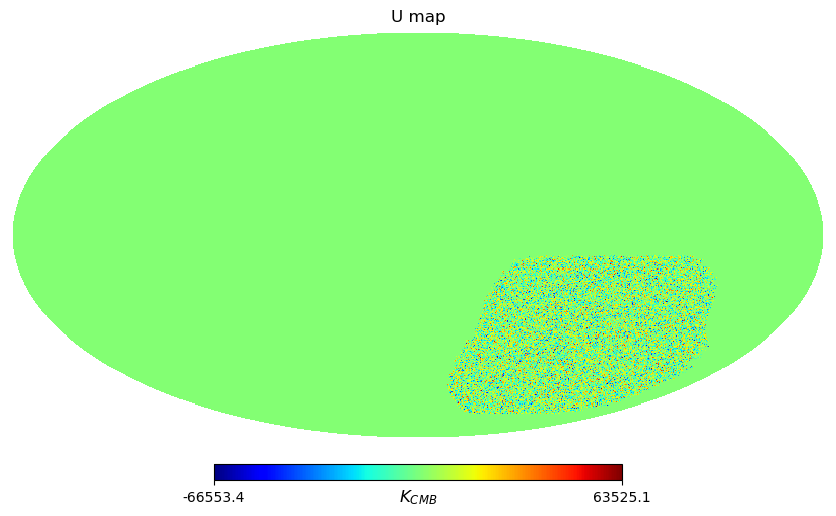

In [13]:
hp.mollview(T_map, cmap='jet', nest= 1, title = 'U map', unit = r'$K_{CMB}$')

In [14]:
toast_so_sim     --log_config config_final.toml     --out_dir out_sat_test     --schedule schedules/schedule_sat_valid.txt     --telescope SAT1     --bands SAT_f090     --sample_rate 10.0     --thinfp 64

SyntaxError: invalid syntax (1912447248.py, line 1)

# TOD

Ahora cargamos los TOD, y de aquí en adelante la idea es trabajar con ellos y recrear mapas.